# 📊 LDH Adsorption – EDA & PCA Analysis
**Dataset:** Micropollutant adsorption trên vật liệu LDH (Layered Double Hydroxide)  
**Mục tiêu:** EDA → PCA compression → Feature engineering → Gradient Boosting (RR% & Qe mg/g)

---
### Cấu trúc notebook
1. Import & Load dữ liệu
2. Tiền xử lý & Chuẩn hóa
3. EDA tổng quan
4. EDA theo nhóm
5. PCA – Micropollutant features (Log Kow, MW, E, S, A, B, V)
6. PCA – Material texture features (BET, PV, APD, pHpzc)
7. Correlation analysis sau PCA
8. Model – Gradient Boosting (RR% & Qe)
9. Feature Importance

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install Boruta BorutaShap "scipy<1.12.0"
!pip install cubist
!pip install optuna

## 1. Import thư viện & Load dữ liệu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.feature_selection import SequentialFeatureSelector as SFS
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

from boruta import BorutaPy
from BorutaShap import BorutaShap

import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.facecolor' : '#F8F9FA',
    'axes.facecolor'   : '#FAFAFA',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
    'axes.titleweight' : 'bold',
    'axes.titlesize'   :  12,
})

SEED = 42
print('✅ Thư viện đã import xong')

✅ Thư viện đã import xong


In [ ]:
# Load dữ liệu
FILE_PATH = '/content/drive/MyDrive/Green-X Project/Data/20260804_Data_Adsorption.xlsx'
df_raw = pd.read_excel(FILE_PATH, sheet_name=0, header=1)   # header nằm ở row 2

print(f'Shape gốc: {df_raw.shape}')
print(f'Cột: {df_raw.columns.tolist()}')

Shape gốc: (1342, 32)
Cột: ['Id', 'TP', 'Log Kow', 'MW g/mol', 'E', 'S', 'A', 'B', 'V', 'TSPA', 'Metal(II) ', 'Metal(III)', 'M(II)/(III)', 'average atomic weight (g/mol)', 'average d-electron', 'average Pauling electronegativity', 'Method', 'TemH oC', 'HT hour', 'Calcination Temp ', 'Calcination time', 'd(003) nm', 'BET m2/g', 'PV cm3/g', 'APD nm', 'pHpzc', 'pH', 'Tem', 'Time h', 'AD g/L', 'Ci mg/L', 'RR %']


In [ ]:
df_raw.head(5)

,Id,TP,Log Kow,MW g/mol,E,S,A,B,V,TSPA,...,BET m2/g,PV cm3/g,APD nm,pHpzc,pH,Tem,Time h,AD g/L,Ci mg/L,RR %
0,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,...,45.17,0.524,46.37,6.9,6.0,25.0,1.000000,0.4,50.0,0.680
1,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,...,45.17,0.524,46.37,6.9,6.0,25.0,0.083333,0.4,50.0,0.120
2,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,...,45.17,0.524,46.37,6.9,6.0,25.0,0.166667,0.4,50.0,0.200
3,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,...,45.17,0.524,46.37,6.9,6.0,25.0,0.250000,0.4,50.0,0.360
4,Amir M. Ramezani_2024,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,...,45.17,0.524,46.37,6.9,6.0,25.0,0.333333,0.4,50.0,0.456


## 2. Tiền xử lý & Chuẩn hóa
- remove unnecessary columns, fill missing value by KNN
- Preprocess numeric columns, encode categorical data


### 2.1 Preprocessing

In [ ]:
df = df_raw.copy()

# Xoá dấu cách ở tên cột
df.columns = df.columns.str.strip()

# Chuẩn hóa biến dạng categorical
df['TP'] = df['TP'].astype(str).str.strip()
df['Metal(II)'] = df['Metal(II)'].astype(str).str.strip().str.title()
df['Metal(III)'] = df['Metal(III)'].astype(str).str.strip()

# Gộp Method không nhất quán
method_map = {
    'urea hydrolysis': 'Urea Hydrolysis',
    'urea Hydrolysis': 'Urea Hydrolysis',
    'co-precipitation or aging': 'Co-precipitation',
    'co-precipitation': 'Co-precipitation',
    'co- precipitation': 'Co-precipitation',
    'reconstruction or memory effect': 'Reconstruction',
}
df['Method'] = df['Method'].astype(str).str.strip().str.lower()
df['Method'] = df['Method'].replace(method_map)
df['Method'] = df['Method'].str.title()  # fallback

# Xử lý RR% (có thể ở dạng % hoặc thập phân)
df['RR %'] = df['RR %'] / 100

# Remove unnecessary columns
df = df.drop(columns=["Id"])

# Display tables
print(f"RR% range: [{df['RR %'].min():.3f}, {df['RR %'].max():.3f}]")
display(df.head(5))

RR% range: [0.000, 0.010]


,TP,Log Kow,MW g/mol,E,S,A,B,V,TSPA,Metal(II),...,BET m2/g,PV cm3/g,APD nm,pHpzc,pH,Tem,Time h,AD g/L,Ci mg/L,RR %
0,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,Zn,...,45.17,0.524,46.37,6.9,6.0,25.0,1.000000,0.4,50.0,0.00680
1,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,Zn,...,45.17,0.524,46.37,6.9,6.0,25.0,0.083333,0.4,50.0,0.00120
2,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,Zn,...,45.17,0.524,46.37,6.9,6.0,25.0,0.166667,0.4,50.0,0.00200
3,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,Zn,...,45.17,0.524,46.37,6.9,6.0,25.0,0.250000,0.4,50.0,0.00360
4,Doxycycline,-0.02,444.43,2.1,3.05,1.55,1.7,2.86,181.62,Zn,...,45.17,0.524,46.37,6.9,6.0,25.0,0.333333,0.4,50.0,0.00456


### 2.2 Missing values

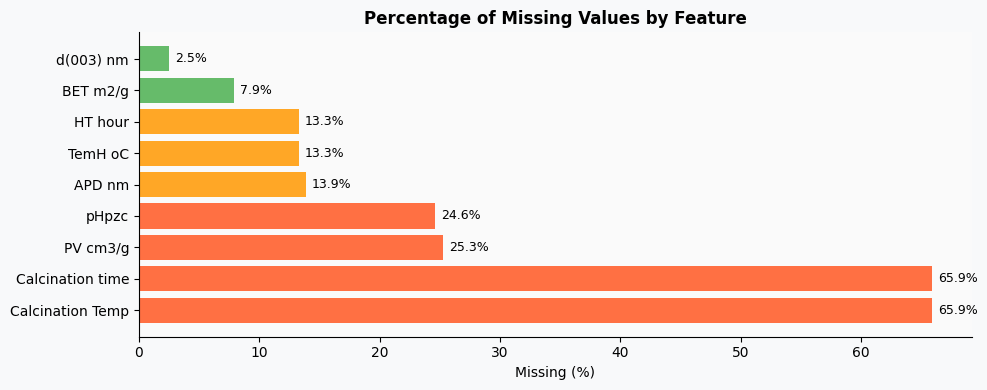

In [ ]:
TARGET_COLS = ["RR %"]
FEATURE_COLS = [col for col in df.columns.to_list() if col not in TARGET_COLS]

# Missign statistic distribution
miss = df[FEATURE_COLS].isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)

miss_df = pd.DataFrame({'Missing count': miss, 'Missing %': miss_pct})
miss_df = miss_df[miss_df['Missing count'] > 0].sort_values('Missing %', ascending=False)

# Visualize
if len(miss_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(miss_df.index, miss_df['Missing %'],
                   color=['#FF7043' if v > 20 else '#FFA726' if v > 10 else '#66BB6A'
                          for v in miss_df['Missing %']])
    ax.set_xlabel('Missing (%)')
    ax.set_title('Percentage of Missing Values by Feature')
    for bar, val in zip(bars, miss_df['Missing %']):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/Green-X Project/Model/missing_values.png", dpi=300)
    plt.show()
else:
    print('No missing values in all columns')

## 3. EDA – Tổng quan

Text(1.1, 0.0020875, 'Q1=0.002')

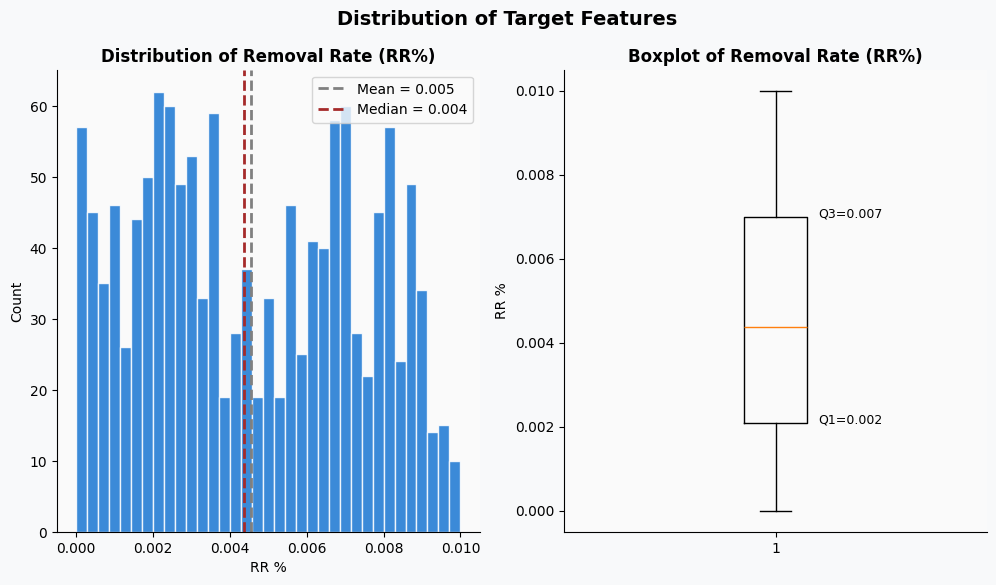

In [ ]:
# Phân phối 2 biến mục tiêu
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Distribution of Target Features', fontsize=14, fontweight='bold')

# RR % – gốc
ax = axes[0]
ax.hist(df['RR %'].dropna(), bins=35, color='#1976D2', edgecolor='white', alpha=0.85)
ax.axvline(df['RR %'].mean(), color='gray', ls='--', lw=2,
           label=f"Mean = {df['RR %'].mean():.3f}")
ax.axvline(df['RR %'].median(), color='brown', ls='--', lw=2,
           label=f"Median = {df['RR %'].median():.3f}")
ax.set_xlabel('RR %'); ax.set_ylabel('Count')
ax.set_title('Distribution of Removal Rate (RR%)'); ax.legend()

# RR % – boxplot
ax = axes[1]
bp = ax.boxplot(df['RR %'].dropna(), vert=True, patch_artist=False)
ax.set_ylabel('RR %'); ax.set_title('Boxplot of Removal Rate (RR%)')
stats_rr = df['RR %'].describe()
ax.text(1.1, stats_rr['75%'], f"Q3={stats_rr['75%']:.3f}", fontsize=9)
ax.text(1.1, stats_rr['25%'], f"Q1={stats_rr['25%']:.3f}", fontsize=9)

## 4. EDA – Phân tích theo nhóm

In [ ]:
# Nhóm A – Micropollutant descriptors
MICRO_COLS = ['Log Kow', 'MW g/mol', 'E', 'S', 'A', 'B', 'V', 'TSPA']

# Nhóm B – Material texture
MAT_COLS = ['d(003) nm', 'BET m2/g', 'PV cm3/g', 'APD nm', 'pHpzc']

# Nhóm C – Adsorbent properties
COMPO_COLS = ['M(II)/(III)', 'average atomic weight (g/mol)', 'average d-electron', 'average Pauling electronegativity']

# Nhóm D - Điều kiện tổng hợp vật liệu
SYNTH_COLS = ['TemH oC', 'HT hour', 'Calcination Temp', 'Calcination time']

# Nhóm D – Điều kiện thí nghiệm
EXP_COLS = ['pH', 'Tem', 'Time h', 'AD g/L', 'Ci mg/L']

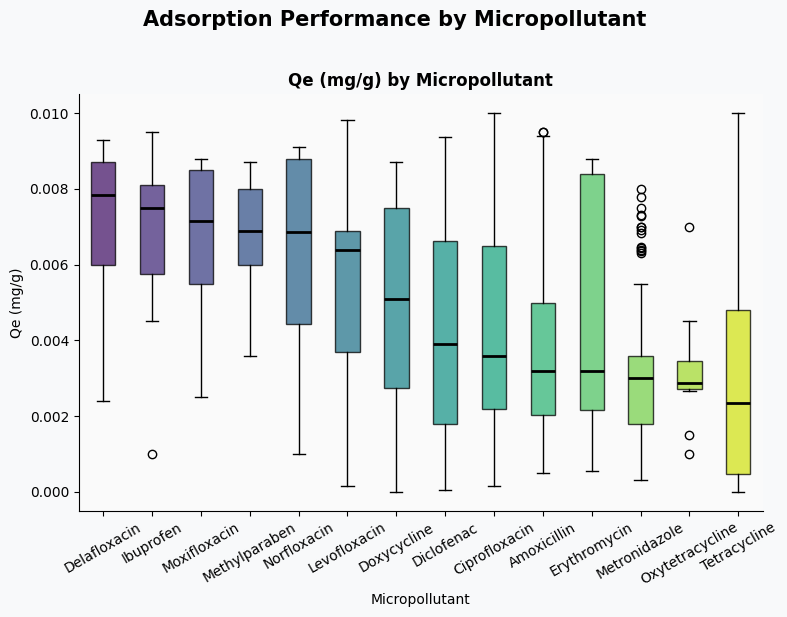

In [ ]:
# RR% theo từng Micropollutant
fig, ax = plt.subplots(figsize=(8, 6))
# Order of micropollutant
order = df.groupby('TP')['RR %'].median().sort_values(ascending=False).index
# Color pallete
palette = sns.color_palette('viridis', len(order))

bp = ax.boxplot(
    [df[df['TP']==tp]['RR %'].dropna().values for tp in order],
    patch_artist=True, labels=order,
    medianprops=dict(color='black', lw=2)
)
for patch, c in zip(bp['boxes'], palette):
    patch.set_facecolor(c); patch.set_alpha(0.75)
ax.set_ylabel('RR%'); ax.set_xlabel('Micropollutant')
ax.set_title('RR% by Micropollutant')
ax.tick_params(axis='x', rotation=30)
ax.set_ylabel('Qe (mg/g)'); ax.set_xlabel('Micropollutant')
ax.set_title('Qe (mg/g) by Micropollutant')
ax.tick_params(axis='x', rotation=30)

plt.suptitle('Adsorption Performance by Micropollutant',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

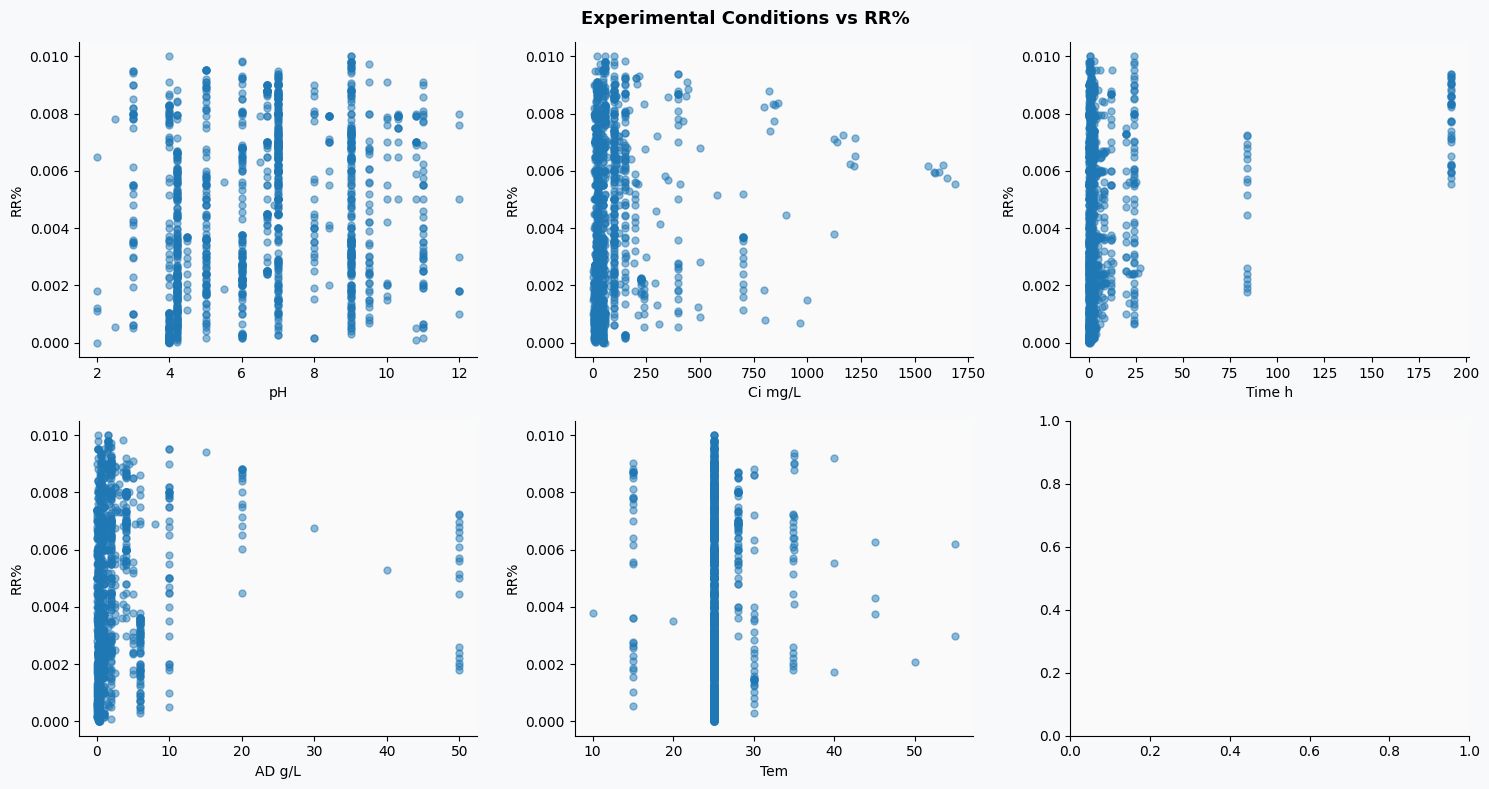

In [ ]:
# Scatter: Experimental conditions vs RR%
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Experimental Conditions vs RR%', fontsize=13, fontweight='bold')
i = 0
for x_col in EXP_COLS:
    ax = axes[i % 2, i % 3]
    sub = df[[x_col, 'RR %']].dropna()
    sc = ax.scatter(sub[x_col], sub[['RR %']], alpha=0.5, s=25)
    ax.set_xlabel(x_col), ax.set_ylabel('RR%')
    i += 1
plt.tight_layout()
plt.show()

## 5. Feature Engineering

### 5.1 KNN Imputation

In [ ]:
# KNN imputer cho các cột
cols_to_impute = [
    'd(003) nm', 'BET m2/g', 'HT hour', 'TemH oC', 'APD nm',
    'pHpzc', 'PV cm3/g', 'Calcination time', "Calcination Temp"
]

# Tạo một bản sao để tránh làm thay đổi dữ liệu gốc
df_imputed = df.copy()
# Chuẩn hóa dữ liệu trước khi dùng KNN
scaler = StandardScaler()
df_imputed[cols_to_impute] = scaler.fit_transform(df_imputed[cols_to_impute])

# Khởi tạo KNNImputer
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
imputed_scaled_values = knn_imputer.fit_transform(df_imputed[cols_to_impute])
# Đưa dữ liệu về lại scale ban đầu (Inverse Transform)
imputed_original_scale = scaler.inverse_transform(imputed_scaled_values)
# Gán lại mảng giá trị đã điền hoàn chỉnh vào DataFrame
df_imputed[cols_to_impute] = imputed_original_scale

print(df_imputed[cols_to_impute].isnull().sum())

d(003) nm           0
BET m2/g            0
HT hour             0
TemH oC             0
APD nm              0
pHpzc               0
PV cm3/g            0
Calcination time    0
Calcination Temp    0
dtype: int64


### 5.2 Categorical Encoding

In [ ]:
cleaned_df = df_imputed.copy()

# Drop unnecessary inputs
cleaned_df = cleaned_df.drop(columns=['TemH oC', 'Calcination time', 'Method', 'TP', 'Metal(II)', 'Metal(III)'])

In [ ]:
CAT_COLS = cleaned_df.select_dtypes(include=["object"]).columns.to_list()

# Label encoded categorical features
le_dict = {}
for col in CAT_COLS:
   le = LabelEncoder()
   cleaned_df[col] = le.fit_transform(cleaned_df[col])
   le_dict[col] = le

### 5.3 Highly-correlated features: Variance Inflator Factor
Evaluate impact of other features on RR%, not other way around to remmove target leakage

👉 Keep Metal(II) and average d-electron so the model know categorical name and a specific numerical characteristics -> remove other "average Pauling electronegativity", "average atomic weight".

👉 Keep BET m2/g and drop PV cm3/g
In porous materials like LDHs, Specific Surface Area (BET) and Total Pore Volume (PV) are physically and mathematically linked during nitrogen adsorption analysis.


👉 Keep MW g/mol (or Log Kow) and drop V, TSPA, S, A, B, E.
All of these variables describe the physical size, shape, and polarity of the target pollutant. As a molecule gets heavier (MW), its volume (V) naturally increases. Its polar surface area (TSPA) and Abraham solvation parameters (S, A, B, E) also shift in highly predictable ways based on that size and structure.


In [ ]:
X = cleaned_df.drop(TARGET_COLS, axis=1).copy()
y = cleaned_df[TARGET_COLS].copy()

# Standardized on X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [ ]:
# Isolate just the independent variables (drop the target!)
target_col = 'RR %'
features_df = cleaned_df.drop(columns=[target_col])

vif_results = {}

# Iterate over all columns in the `cleaned_df` to compute VIF for each
for feature_col in features_df.columns:

    y_vif = features_df[feature_col]
    X_vif = features_df.drop(columns=[feature_col])

    linreg = LinearRegression()
    linreg.fit(X_vif, y_vif)

    r_squared = linreg.score(X_vif, y_vif)

    if np.isclose(1 - r_squared, 0):
        vif_score = np.inf
    else:
        vif_score = 1 / (1 - r_squared)

    vif_results[feature_col] = vif_score

vif_df = pd.DataFrame(list(vif_results.items()), columns=["Feature", "VIF"])
vif_df.sort_values(by=["VIF"], ascending=False, inplace=True)

display(vif_df)

,Feature,VIF
6,V,121.524277
1,MW g/mol,120.096926
10,average d-electron,104.706869
9,average atomic weight (g/mol),91.634955
7,TSPA,79.757072
3,S,72.233583
5,B,44.311414
4,A,34.665001
2,E,25.750589
16,PV cm3/g,19.532426


### 5.3 Low-importance features: BorutaShap

By using SHAP Values as the feature selection method in BorutaShap, we get the Boruta SHAP Feature Selection Algorithm. With this approach we can get the strong addictive feature explanations existent in SHAP method while having the robustness of Boruta algorithm to ensure only significant variables remain on the set.

In [ ]:
# Creates a BorutaShap selector for regression
selector = BorutaShap(importance_measure = 'shap', classification = False)
# Fits the selector for RR mg/g
selector.fit(X = X, y = np.array(y)[:, 0], n_trials = 20, sample = False, verbose=True)
features_to_remove = selector.features_to_remove
print(features_to_remove)

  0%|          | 0/20 [00:00<?, ?it/s]

16 attributes confirmed important: ['TSPA', 'pH', 'pHpzc', 'Time h', 'S', 'E', 'BET m2/g', 'PV cm3/g', 'B', 'Log Kow', 'AD g/L', 'average Pauling electronegativity', 'd(003) nm', 'Ci mg/L', 'average atomic weight (g/mol)', 'APD nm']
7 attributes confirmed unimportant: ['Calcination Temp', 'M(II)/(III)', 'Tem', 'V', 'A', 'average d-electron', 'MW g/mol']
1 tentative attributes remains: ['HT hour']
['MW g/mol' 'A' 'V' 'M(II)/(III)' 'average d-electron' 'Calcination Temp'
 'Tem']


Tem (Temperature) và HT hour (Hydrothermal Time) đều bị thuật toán kết luận là "unimportant" cho cả hai mục tiêu.

$\rightarrow$ kết quả đo lường đã có đủ thông tin từ điều kiện tổng hợp

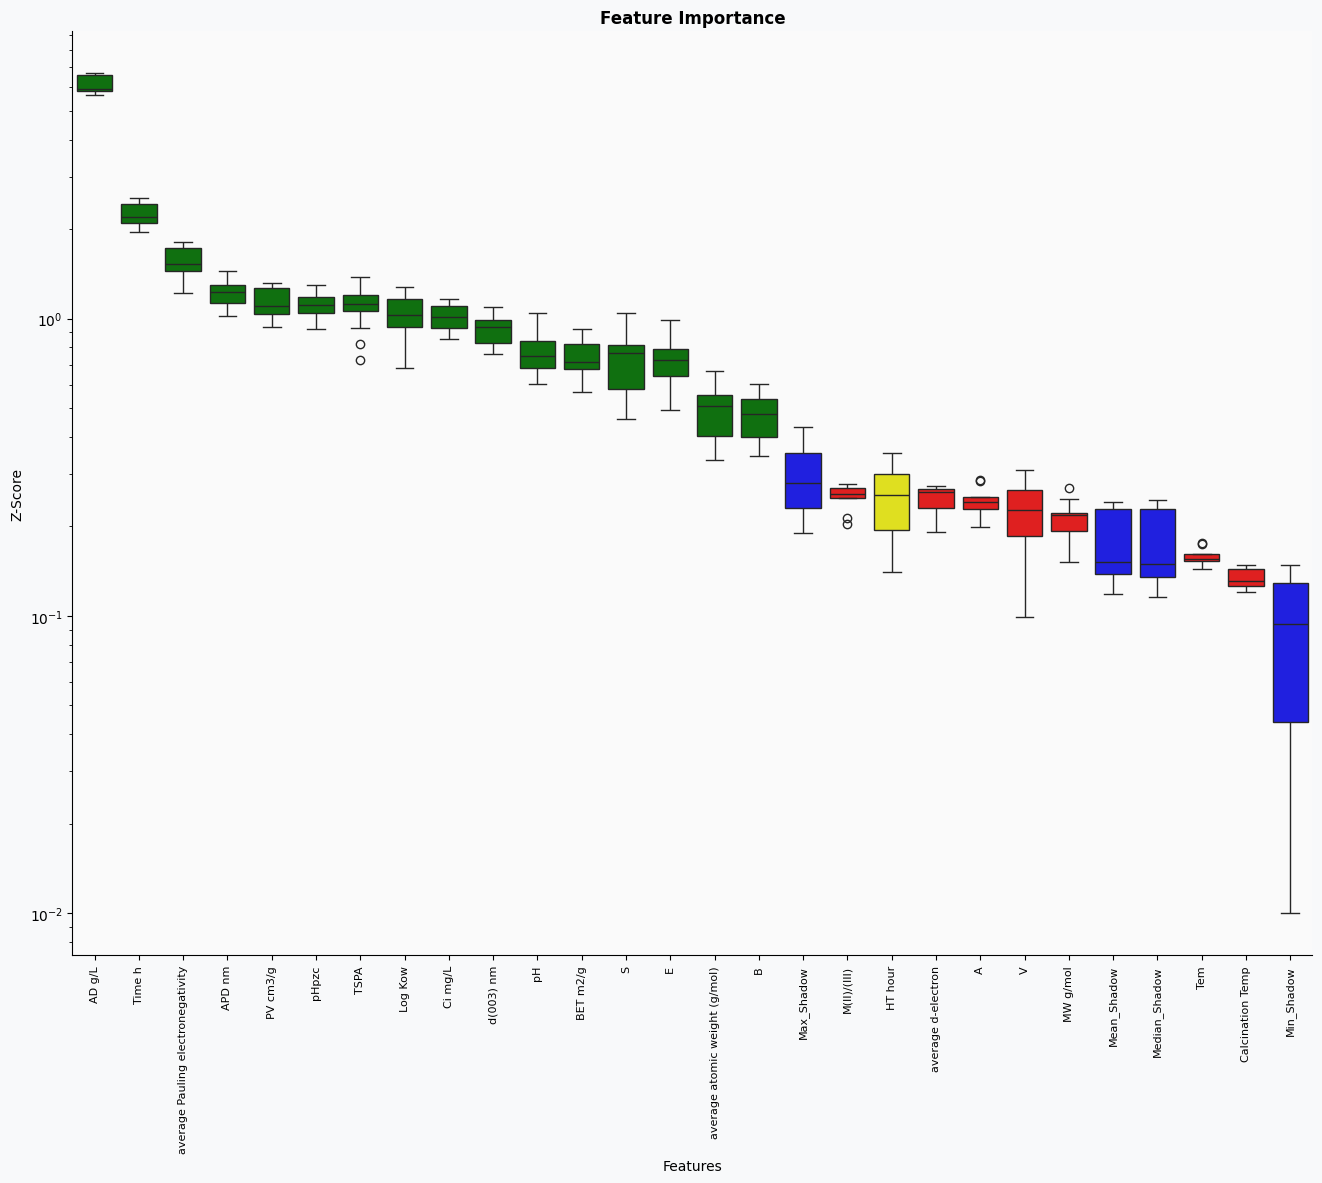

In [ ]:
selector.plot(which_features="all", figsize=(16, 12))

### 5.4 Stat Correlation

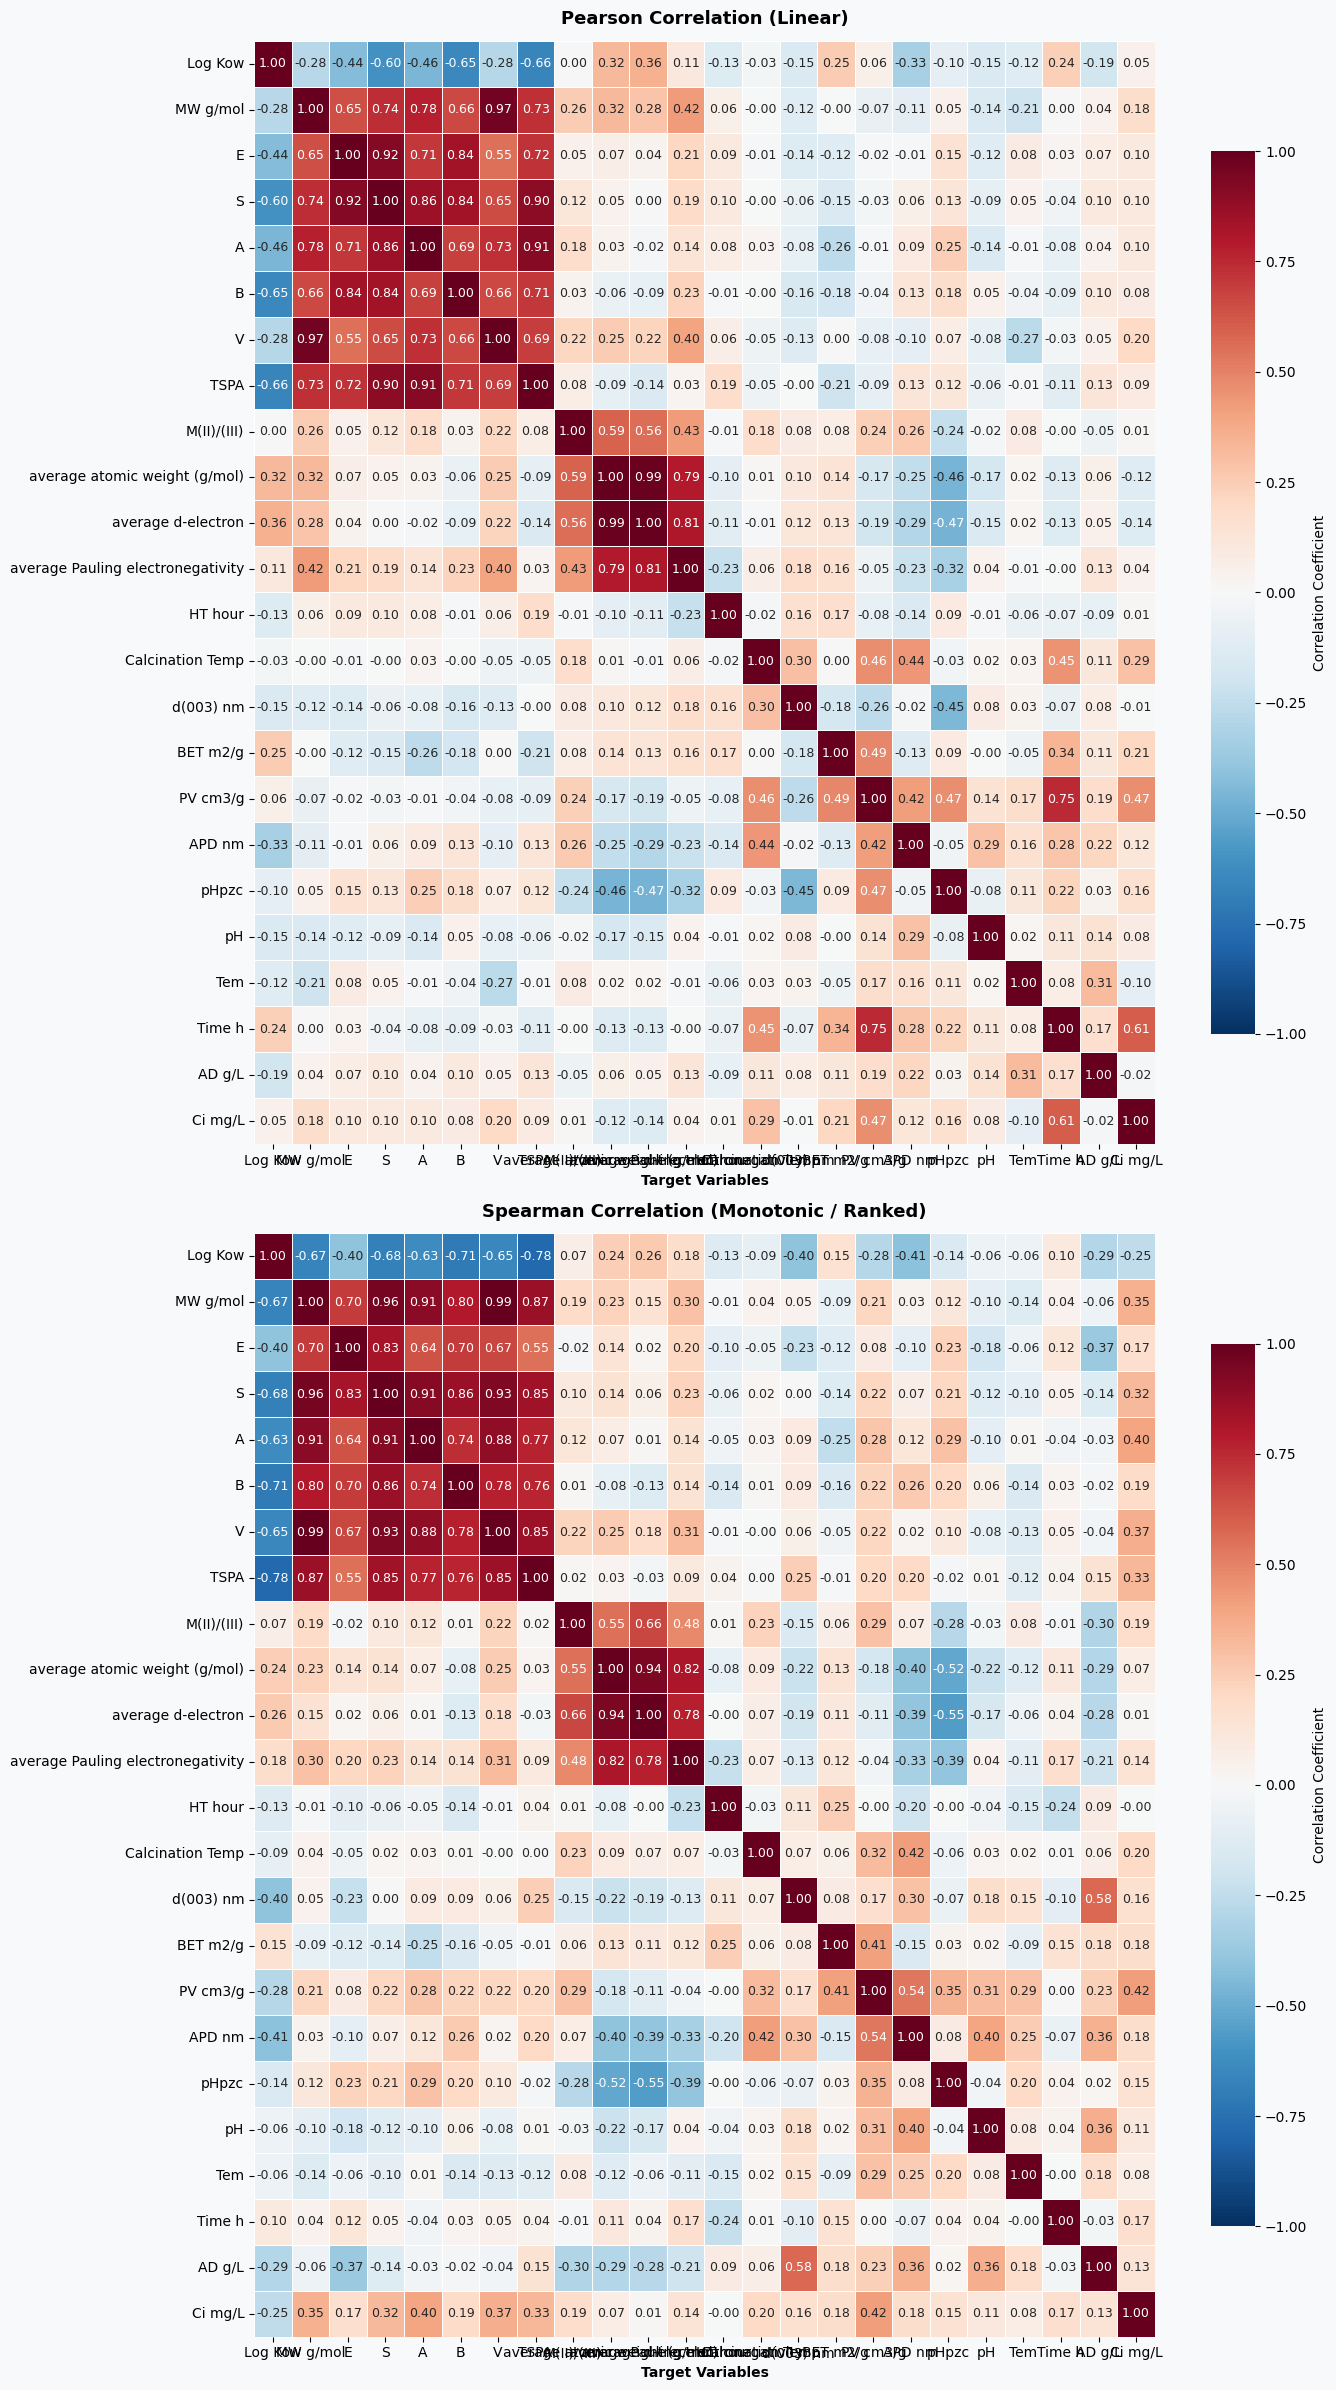

In [ ]:
# Xác định targets và features
TARGETS = ["RR %"]
NUMERIC_COLS = cleaned_df.select_dtypes(include="number").columns.to_list()
FEATURES = [col for col in NUMERIC_COLS if col not in TARGETS]

# Tính ma trận tương quan cho cả 2 method (chỉ lấy Features vs Targets)
corr_pearson = cleaned_df[NUMERIC_COLS].corr(method="pearson").loc[FEATURES, FEATURES]
corr_spearman = cleaned_df[NUMERIC_COLS].corr(method="spearman").loc[FEATURES, FEATURES]

# 3. Trực quan hóa song song 2 Heatmap
fig, axes = plt.subplots(2, 1, figsize=(14, max(6, len(FEATURES))), sharey=True)

# Common heatmap arguments
heatmap_kws = dict(
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    annot_kws={"size": 9},
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
)

# --- Subplot 1: Pearson (Linear) ---
sns.heatmap(corr_pearson, ax=axes[0], **heatmap_kws)
axes[0].set_title(
    "Pearson Correlation (Linear)", fontsize=13, fontweight="bold", pad=12
)
axes[0].set_xlabel("Target Variables", fontweight="bold", fontsize=10)
axes[0].tick_params(axis="x", rotation=0, labelsize=10)
axes[0].tick_params(axis="y", labelsize=10)

# --- Subplot 2: Spearman (Monotonic / Ranked) ---
sns.heatmap(corr_spearman, ax=axes[1], **heatmap_kws)
axes[1].set_title(
    "Spearman Correlation (Monotonic / Ranked)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
axes[1].set_xlabel("Target Variables", fontweight="bold", fontsize=10)
axes[1].tick_params(axis="x", rotation=0, labelsize=10)
axes[1].set_ylabel("")  # Ẩn nhãn y vì đã sharey với subplot trái

plt.tight_layout()
plt.show()

## 6. RR % Prediction
* Split data 80/20 and train 5 models on 5-fold cross validation.
* Models comparison: LR, KNN, Cubist, ANN, DNN, HistGradientBoostingRegressor
* MAE (càng thấp càng tốt): HistGB ⭐ > KNN > XGB > RF > Cubist > LR > ANN
* R^2 (càng cao càng tốt): HistGB ⭐> XGB > RF > KNN > Cubist >LR > ANN

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from cubist import Cubist
from xgboost import XGBRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_validate, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
SEED = 42

In [ ]:
# Experiment 2: Drop highly correlated features
X = X.drop(columns=["MW g/mol", "E", "S", "A", "B", "V", "average Pauling electronegativity", "average atomic weight (g/mol)", "PV cm3/g"])

# Experiment 3
# X = X.drop(columns=["MW g/mol", "average d-electron", "A", "V", 'Tem', 'HT hour', 'Calcination Temp', "Method"])

# Experiment 4: Wrapper-based method (Sequential feature selection)
# rf_proxy = RandomForestRegressor(n_estimators=50, random_state=42)
# sfs = SFS(
#     estimator=rf_proxy,
#     n_features_to_select=22,
#     direction="forward",
#     cv=5
# )

# sfs = sfs.fit(X_scaled, y)

# # Return optimal set of features
# print(sfs.get_feature_names_out())

# Experiment 5 (another Boruta but eliminate some initial inputs)
# X = X.drop(columns=['Calcination Temp', 'M(II)/(III)', 'Tem', 'V', 'A', 'average d-electron', 'MW g/mol'])

# Experiment 6 (same with ex.5 but add V and A)
# X = X.drop(columns=['Calcination Temp', 'M(II)/(III)', 'Tem', 'average d-electron', 'MW g/mol'])

In [ ]:
# Convert to array
y_rr = np.array(y)
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y_rr, test_size=0.2)

# Reduce data to selected features
# X_train = sfs.transform(X_train)f
# X_test = sfs.transform(X_test)

# Lấy số lượng biến đầu vào để thiết lập cho lớp ẩn của ANN
n_input_features = X_train.shape[1]

# Khởi tạo K-Fold với n_splits=5
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

# ==========================================
# 1. THIẾT LẬP PIPELINE & GRID SEARCH
# ==========================================

# --- Linear Regression ---
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# --- KNN (Tối ưu hóa n_neighbors từ 1 đến 10 dựa trên MAE) ---
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', KNeighborsRegressor())
])
knn__param_grid = {
    'regressor__n_neighbors': list(range(1, 10))
}
# scoring='neg_mean_absolute_error' để minimize MAE
knn_grid = GridSearchCV(knn_pipe, knn__param_grid, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)

# --- ANN (1 lớp ẩn với ReLU, số neuron = 32) ---
ann_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', MLPRegressor(
        hidden_layer_sizes=(32,),
        activation='relu',
        solver='adam',
        max_iter=2000,
        random_state=SEED
    ))
])

# --- CUBIST (Tối ưu hóa committees và neighbors dựa trên MSE) ---
cubist_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Cubist())
])
cubist__param_grid = {
    'regressor__n_committees': list(range(1, 10)),
    'regressor__neighbors': list(range(0, 9))
}
# scoring='neg_mean_squared_error' để minimize MSE
cubist_grid = GridSearchCV(cubist_pipe, cubist__param_grid, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)

# --- Tree-based models (HistGradientBoostingRegressor and XGBoost) ---
# HistGradientBoostingRegressor
def tune_hgb_optuna(X, y, cv, n_trials=30):
    """Tìm tham số tối ưu cho HistGradientBoostingRegressor"""
    print("--- Đang chạy Optuna cho HistGradientBoostingRegressor... ---")

    def objective(trial):
        params = {
            'max_iter': trial.suggest_int('max_iter', 100, 600),
            # log=True rất quan trọng để Optuna phân phối đều các giá trị nhỏ (0.0001, 0.001, 0.01)
            'learning_rate': trial.suggest_float('learning_rate', 0.0001, 1.0, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 3, 9),
        }

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', HistGradientBoostingRegressor(**params, random_state=42))
        ])

        # Đánh giá bằng Cross Validation (trả về Negative MAE)
        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
        return -scores.mean()

    # Tạo study để Maximize vì scikit-learn trả về số âm cho các hàm lỗi (càng gần 0 càng tốt)
    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)

    print(f"[*] HistGradientBoosting - Tìm thấy tham số tốt nhất: {study.best_params}")
    return study.best_params

# XGBoost
def tune_xgb_optuna(X, y, cv, n_trials=30):
    """Tìm tham số tối ưu cho XGBoost"""
    print("--- Đang chạy Optuna cho XGBoost... ---")

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 600),
            'learning_rate': trial.suggest_float('learning_rate', 0.0001, 1.0, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'min_child_weight': trial.suggest_int('min_child_weight', 3, 9),
        }

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', XGBRegressor(**params, random_state=42, n_jobs=-1))
        ])

        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
        return -scores.mean()

    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials)

    print(f"[*] XGBoost - Tìm thấy tham số tốt nhất: {study.best_params}")
    return study.best_params

# Random Forest
def tune_rf_optuna(X, y, cv, n_trials=30):
    """Tìm tham số tối ưu cho Random Forest Regressor"""
    print("--- Đang chạy Optuna cho Random Forest Regressor ... ---")

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 600),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 3, 9),
        }

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', RandomForestRegressor(**params, random_state=SEED, n_jobs=-1))
        ])

        scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
        return -scores.mean()

    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials)

    print(f"[*] RandomForestRegressor - Tìm thấy tham số tốt nhất: {study.best_params}")
    return study.best_params

# Chạy Optuna để lấy dict tham số (giả sử set n_trials=30 vòng cho mỗi thuật toán)
best_hgb_params = tune_hgb_optuna(X_train, y_train, cv=kf, n_trials=30)
best_xgb_params = tune_xgb_optuna(X_train, y_train, cv=kf, n_trials=30)
best_rf_params = tune_rf_optuna(X_train, y_train, cv=kf, n_trials=30)

# Tạo Pipeline mới với tham số tối ưu vừa tìm được
optimized_hgb_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', HistGradientBoostingRegressor(**best_hgb_params, random_state=SEED))
])

optimized_xgb_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', XGBRegressor(**best_xgb_params, random_state=SEED, n_jobs=-1))
])

optimized_rf_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(**best_rf_params, random_state=SEED, n_jobs=-1))
])

# ==========================================
# 2. HUẤN LUYỆN VÀ ĐÁNH GIÁ (CROSS-VALIDATION & TEST SET)
# ==========================================

def evaluate_model(model_or_grid, X_tr, y_tr, X_te, y_te, cv, model_name, is_grid=False):
    """
    Hàm huấn luyện, đánh giá K-Fold CV trên tập Train và kiểm tra trên tập Test.
    """
    print(f"--- Đang xử lý {model_name}... ---")

    # XÁC ĐỊNH MÔ HÌNH TỐI ƯU (ESTIMATOR)
    if is_grid:
        # Chạy GridSearch để tìm tham số tốt nhất
        model_or_grid.fit(X_tr, y_tr)
        best_model = model_or_grid.best_estimator_

        # In ra cấu hình tối ưu
        clean_params = {k.replace('regressor__', ''): v for k, v in model_or_grid.best_params_.items()}
        print(f"[*] Cấu hình tối ưu tìm được: {clean_params}")
    else:
        # Chạy luôn pipeline đầu vào
        best_model = model_or_grid

    # 2. ĐÁNH GIÁ K-FOLD CV TRÊN TẬP TRAIN
    # Đánh giá metrics trên model tốt nhất
    scoring = {
        'r2': 'r2',
        'neg_mae': 'neg_mean_absolute_error',
        'neg_rmse': 'neg_root_mean_squared_error',
    }

    cv_results = cross_validate(best_model, X_tr, y_tr, cv=cv, scoring=scoring, return_train_score=False)
    cv_r2_mean = np.mean(cv_results['test_r2'])
    cv_mae_mean = -np.mean(cv_results['test_neg_mae'])
    cv_rmse_mean = -np.mean(cv_results['test_neg_rmse'])

    print(f"[*] CV (Train Set) Mean R^2 : {cv_r2_mean:.4f}")
    print(f"[*] CV (Train Set) Mean MAE : {cv_mae_mean:.4f}")
    print(f"[*] CV (Train Set) Mean RMSE : {cv_rmse_mean:.4f}")

    # 3. ĐÁNH GIÁ TRÊN TẬP TEST
    # Fit lại mô hình trên dữ liệu Train
    best_model.fit(X_tr, y_tr)

    # Dự đoán và tính điểm
    y_pred = best_model.predict(X_te)
    test_r2 = r2_score(y_te, y_pred)
    test_mae = mean_absolute_error(y_te, y_pred)
    test_rmse = root_mean_squared_error(y_te, y_pred)

    print(f"Kết quả Test Set (Hold-out):")
    print(f"    Test R^2 : {test_r2:.4f}")
    print(f"    Test MAE : {test_mae:.4f}")
    print(f"    Test RMSE : {test_rmse:.4f}\n")

    return dict(model=best_model, y_te=y_te, y_pred=y_pred,
                r2=cv_r2_mean, mae=cv_mae_mean, label=model_name)

--- Đang chạy Optuna cho HistGradientBoostingRegressor... ---
[*] HistGradientBoosting - Tìm thấy tham số tốt nhất: {'max_iter': 507, 'learning_rate': 0.24227423346698446, 'max_depth': 9, 'min_samples_leaf': 6}
--- Đang chạy Optuna cho XGBoost... ---
[*] XGBoost - Tìm thấy tham số tốt nhất: {'n_estimators': 430, 'learning_rate': 0.008842975348682268, 'max_depth': 11, 'min_child_weight': 3}
--- Đang chạy Optuna cho Random Forest Regressor ... ---
[*] RandomForestRegressor - Tìm thấy tham số tốt nhất: {'n_estimators': 484, 'max_depth': 13, 'min_samples_leaf': 3}


In [ ]:
# Gọi hàm cho các mô hình
res_rr_lr = evaluate_model(lr_pipe, X_train, y_train, X_test, y_test, cv=kf, model_name="LR", is_grid=False)
res_rr_knn = evaluate_model(knn_grid, X_train, y_train, X_test, y_test, cv=kf, model_name="KNN", is_grid=True)
res_rr_ann = evaluate_model(ann_model, X_train, y_train, X_test, y_test, cv=kf, model_name="ANN", is_grid=False)
res_rr_cubist = evaluate_model(cubist_grid, X_train, y_train, X_test, y_test, cv=kf, model_name="Cubist", is_grid=True)
res_rr_hgb = evaluate_model(optimized_hgb_model, X_train, y_train, X_test, y_test, cv=kf, model_name="HistGB", is_grid=False)
res_rr_xgb = evaluate_model(optimized_xgb_model, X_train, y_train, X_test, y_test, cv=kf, model_name="XGB", is_grid=False)
res_rr_rf = evaluate_model(optimized_rf_model, X_train, y_train, X_test, y_test, cv=kf, model_name="RF", is_grid=False)

--- Đang xử lý LR... ---
[*] CV (Train Set) Mean R^2 : 0.2916
[*] CV (Train Set) Mean MAE : 0.0019
[*] CV (Train Set) Mean RMSE : 0.0023
Kết quả Test Set (Hold-out):
    Test R^2 : 0.2690
    Test MAE : 0.0021
    Test RMSE : 0.0025

--- Đang xử lý KNN... ---
[*] Cấu hình tối ưu tìm được: {'n_neighbors': 1}
[*] CV (Train Set) Mean R^2 : 0.7471
[*] CV (Train Set) Mean MAE : 0.0008
[*] CV (Train Set) Mean RMSE : 0.0014
Kết quả Test Set (Hold-out):
    Test R^2 : 0.8232
    Test MAE : 0.0006
    Test RMSE : 0.0012

--- Đang xử lý ANN... ---
[*] CV (Train Set) Mean R^2 : -436.9627
[*] CV (Train Set) Mean MAE : 0.0333
[*] CV (Train Set) Mean RMSE : 0.0576
Kết quả Test Set (Hold-out):
    Test R^2 : -324.4319
    Test MAE : 0.0318
    Test RMSE : 0.0524

--- Đang xử lý Cubist... ---
[*] Cấu hình tối ưu tìm được: {'n_committees': 9, 'neighbors': 2}
[*] CV (Train Set) Mean R^2 : 0.6957
[*] CV (Train Set) Mean MAE : 0.0011
[*] CV (Train Set) Mean RMSE : 0.0015
Kết quả Test Set (Hold-out):
    T

## 7. Best performance viz

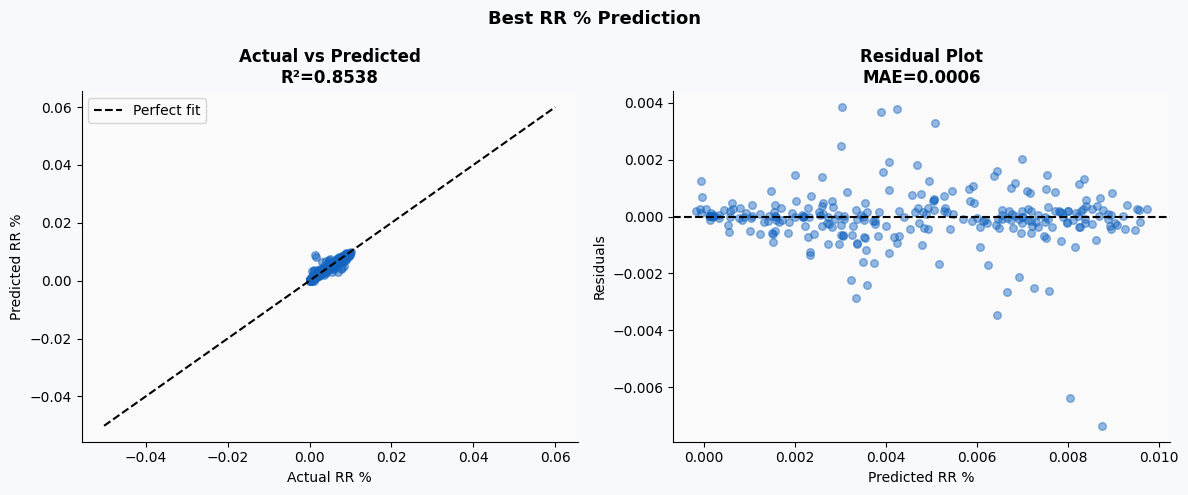

In [ ]:
label = 'RR %'
# Manual label
y_t, y_p = res_rr_hgb['y_te'], res_rr_hgb['y_pred']
color = '#1565C0'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'Best {label} Prediction', fontsize=13, fontweight='bold')

# Actual vs Predicted
ax = axes[0]
ax.scatter(y_t, y_p, alpha=0.5, s=30, color=color)
lo, hi = min(y_t.min(), y_p.min())-0.05, max(y_t.max(), y_p.max())+0.05
ax.plot([lo,hi],[lo,hi],'k--',lw=1.5,label='Perfect fit')
ax.set_xlabel(f'Actual {label}'); ax.set_ylabel(f'Predicted {label}')
ax.set_title(f'Actual vs Predicted\nR²={res_rr_hgb["r2"]:.4f}')
ax.legend()

# Residuals
ax = axes[1]
residuals = y_t - y_p.reshape(-1, 1)
ax.scatter(y_p, residuals, alpha=0.45, s=30, color=color)
ax.axhline(0, color='black', ls='--', lw=1.5)
ax.set_xlabel(f'Predicted {label}'); ax.set_ylabel('Residuals')
ax.set_title(f'Residual Plot\nMAE={res_rr_hgb["mae"]:.4f}')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Green-X Project/Model/model_results.png", dpi=300)
plt.show()

## 8. Save model artifacts

In [ ]:
import joblib

In [ ]:
trained_models = {
    "LR": res_rr_lr['model'],
    "KNN": res_rr_knn['model'],
    "ANN": res_rr_ann['model'],
    "Cubist": res_rr_cubist['model'],
    "HistGB": res_rr_hgb['model'],
    "XGB": res_rr_xgb['model'],
    "RF": res_rr_rf['model']
}

# Save the entire dictionary to a single file
joblib.dump(trained_models, '/content/drive/MyDrive/Green-X Project/Model/saved_models.joblib')
print("All models successfully saved to 'saved_models.joblib'")

All models successfully saved to 'saved_models.joblib'


## 9. Permutation Importance – Tổng hợp & So sánh
* Permutation Importance for LR, XGB, RF, HistGB, Cubist

$\rightarrow$ Linear Regression as the most robust to noise


In [ ]:
from sklearn.inspection import permutation_importance
import shap

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
import copy

def extract_feature_ranks(model, feature_names, X_df, y_df):
    """
    Hàm trích xuất và xếp hạng độ quan trọng của biến từ các loại mô hình khác nhau.
    Rank 1 = Quan trọng nhất.
    """
    X_selected = X_df[feature_names]
    # Assuming 'model' is a Pipeline. permutation_importance can take a pipeline directly.
    result = permutation_importance(model, X_selected, y_df, n_repeats=10, random_state=SEED, n_jobs=-1)
    importances = result.importances_mean
    # Chuyển importances thành DataFrame để dễ xếp hạng (Ranking)
    df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

    # Xếp hạng: Giá trị lớn nhất -> Rank 1
    df_imp['Rank'] = df_imp['Importance'].rank(ascending=False, method='min')

    return df_imp.set_index('Feature')['Rank'].to_dict()


def evaluate_feature_importance_methods(X, y, base_models):
    """
    Tiêm nhiễu với các scale khác nhau và theo dõi thứ hạng của biến 'random'.
    """
    scales = [0.001, 10, 1000]
    results = []

    # Get feature names from the original DataFrame before initial scaling in cell bL6fMytmQ7hP.
    # This ensures that when X (the numpy array) is converted to a DataFrame,
    # it has meaningful column names, allowing 'random_noise' to be added as a column.
    # `cleaned_df` and `TARGET_COLS` are global variables from earlier cells.
    initial_feature_names = cleaned_df.drop(TARGET_COLS, axis=1).columns.tolist()

    for scale in scales:
        print(f"--- Đang kiểm thử với Noise Scale: {scale} ---")

        # 1. Convert X (numpy array) to a DataFrame to allow adding the 'random_noise' column
        X_current_df = pd.DataFrame(X, columns=initial_feature_names)
        X_noisy_df = X_current_df.copy() # Now X_noisy_df is a DataFrame

        # Tạo dữ liệu ngẫu nhiên phân phối chuẩn, sau đó nhân với scale
        np.random.seed(SEED) # Use global SEED
        X_noisy_df['random_noise'] = np.random.randn(len(X)) * scale

        features_noisy = X_noisy_df.columns.tolist()

        # 2. Huấn luyện và trích xuất thứ hạng cho từng mô hình
        for model_name, model_info in base_models.items():
            regressor = model_info['model']

            # Create a deep copy of the model pipeline to avoid modifying the original
            test_regressor = copy.deepcopy(regressor)

            # Huấn luyện trên tập dữ liệu đã có nhiễu (DataFrame)
            # The pipeline 'test_regressor' is expected to handle scaling internally if needed.
            test_regressor.fit(X_noisy_df, y)

            # Trích xuất xếp hạng - Pass the DataFrame with noise and its feature names
            ranks = extract_feature_ranks(test_regressor, features_noisy, X_noisy_df, y)

            # Lưu lại kết quả thứ hạng của riêng biến 'random_noise'
            noise_rank = ranks.get('random_noise', np.nan) # Use .get to avoid KeyError if 'random_noise' is somehow missing

            results.append({
                'Model': model_name,
                'Noise Scale': scale,
                'Noise Rank': noise_rank
            })

    # Chuyển kết quả thành DataFrame để dễ nhìn
    results_df = pd.DataFrame(results)
    pivot_results = results_df.pivot(index='Model', columns='Noise Scale', values='Noise Rank')

    print(f"\n[ KẾT QUẢ ] Thứ hạng của biến nhiễu 'random_noise' (Rank 1 là quan trọng nhất, Rank {X_noisy_df.shape[1]} là kém nhất)")
    print(pivot_results)
    return pivot_results

In [ ]:
# Khai báo dictionary chứa các mô hình cần đánh giá
models_to_test_rr = {
    'Linear Regression': {
        'model': res_rr_lr["model"],
        'type': 'LR'
    },
    'HistGradientBoosting': {
        'model': res_rr_hgb["model"],
        'type': 'HistGB'
    },
    'Random Forest': {
        'model': res_rr_rf["model"],
        'type': 'RF'
    },
    'XGBoost': {
        'model': res_rr_xgb["model"],
        'type': 'XGB'
    },
    'Cubist': {
        'model': res_rr_cubist["model"],
        'type': 'Cubist'
    }
}

# Chạy thử nghiệm
pivot_table_rr = evaluate_feature_importance_methods(X_scaled, y_rr, models_to_test_rr)

# Save result table
pivot_table_rr.to_csv("/content/drive/MyDrive/Green-X Project/Model/permutation_importance.csv", index=False)

print(pivot_table_rr)

--- Đang kiểm thử với Noise Scale: 0.001 ---
--- Đang kiểm thử với Noise Scale: 10 ---
--- Đang kiểm thử với Noise Scale: 1000 ---

[ KẾT QUẢ ] Thứ hạng của biến nhiễu 'random_noise' (Rank 1 là quan trọng nhất, Rank 25 là kém nhất)
Noise Scale           0.001     10.000    1000.000
Model                                             
Cubist                     3.0       3.0       3.0
HistGradientBoosting       8.0       8.0       8.0
Linear Regression         23.0      23.0      23.0
Random Forest             12.0      12.0      12.0
XGBoost                   13.0      13.0      13.0
Noise Scale           0.001     10.000    1000.000
Model                                             
Cubist                     3.0       3.0       3.0
HistGradientBoosting       8.0       8.0       8.0
Linear Regression         23.0      23.0      23.0
Random Forest             12.0      12.0      12.0
XGBoost                   13.0      13.0      13.0


In [ ]:
# selected_features = sfs.get_feature_names_out()
lr_rank_rr = extract_feature_ranks(res_rr_lr["model"], X_train.columns, X_scaled, y_rr)
rank_df_rr = pd.Series(lr_rank_rr).to_frame(name='Rank').sort_values(by="Rank")
print(rank_df_rr)

                                   Rank
TSPA                                1.0
average d-electron                  2.0
A                                   3.0
average atomic weight (g/mol)       4.0
Log Kow                             5.0
B                                   6.0
Calcination Temp                    7.0
average Pauling electronegativity   8.0
V                                   9.0
PV cm3/g                           10.0
MW g/mol                           11.0
S                                  12.0
Time h                             13.0
HT hour                            14.0
pH                                 15.0
AD g/L                             16.0
APD nm                             17.0
pHpzc                              18.0
Ci mg/L                            19.0
BET m2/g                           20.0
Tem                                21.0
M(II)/(III)                        22.0
E                                  23.0
d(003) nm                          24.0


In [ ]:
xgb_rank_rr = extract_feature_ranks(res_rr_xgb["model"], X_train.columns, X_scaled, y_rr)
rank_df_rr = pd.Series(xgb_rank_rr).to_frame(name='Rank').sort_values(by="Rank")
print(rank_df_rr)

                                   Rank
AD g/L                              1.0
Time h                              2.0
Log Kow                             3.0
MW g/mol                            4.0
pH                                  5.0
PV cm3/g                            6.0
Ci mg/L                             7.0
average Pauling electronegativity   8.0
BET m2/g                            9.0
APD nm                             10.0
d(003) nm                          11.0
E                                  12.0
pHpzc                              13.0
M(II)/(III)                        14.0
B                                  15.0
average atomic weight (g/mol)      16.0
V                                  17.0
Calcination Temp                   18.0
Tem                                19.0
HT hour                            20.0
TSPA                               21.0
S                                  22.0
A                                  23.0
average d-electron                 24.0


PermutationExplainer explainer: 270it [02:58,  1.44it/s]


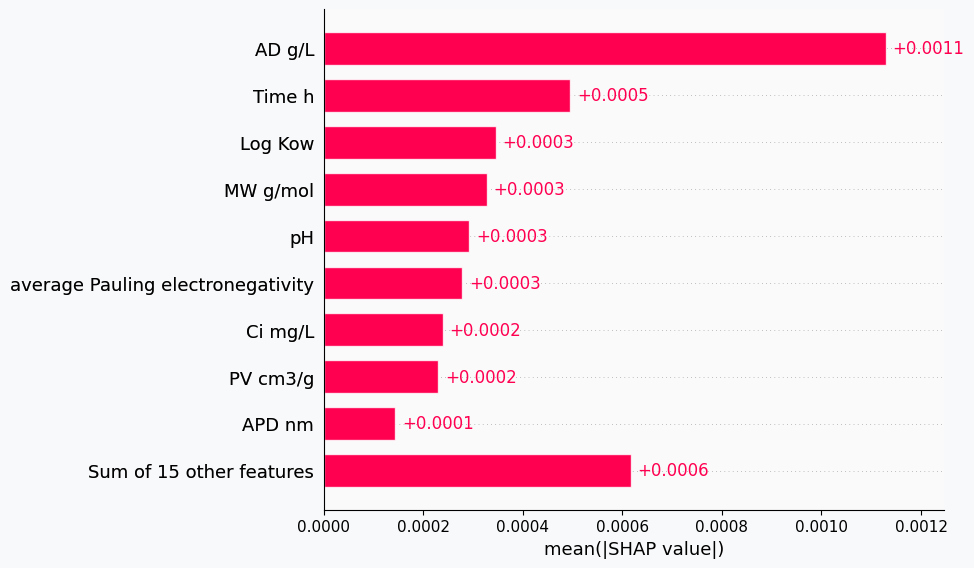

In [ ]:
# Create a background dataset from X_train (100-200 rows is optimal for speed)
background_data = shap.sample(X_train, 1342)

# Pass the .predict method explicitly for regression models
explainer_rr_xgb = shap.Explainer(res_rr_xgb["model"].predict, background_data)

# Compute SHAP values strictly on the test set (or a subset of test set)
shap_values_rr = explainer_rr_xgb(X_test)

# Generate the plot but do not show it yet
shap.plots.bar(shap_values_rr, show=False)

# Get the current axes so we can modify the labels
ax = plt.gca()

# Iterate through the bars (patches) and the text labels simultaneously
for patch, text in zip(ax.patches, ax.texts):
    # Get the actual numeric value (the width of the bar)
    true_value = patch.get_width()

    # Update the text label to show 4 decimal places
    text.set_text(f"+{true_value:.4f}")

# Save and show
plt.savefig('/content/drive/MyDrive/Green-X Project/Model/shap_bar_plot.png', dpi=300, bbox_inches='tight')
plt.show()